## QAOA vs exact solver — timing sweep

Synthetic covariance, `PortfolioOptimization` → QP, then **NumPy minimum eigensolver** vs **QAOA** (simulated). SciPy `SparseEfficiencyWarning` messages are suppressed; times use `time.perf_counter()`.

**Takeaway:** On a **classical simulator**, QAOA is almost always **slower in wall time** than a direct classical eigensolver for small problems — your table (large `qaoa/exact` ratios) is exactly what we expect. The next section asks a *different* question: can QAOA **beat a weak classical search** on **solution quality** (objective value), not on clock speed?


   n     exact [s]      qaoa [s]    qaoa/exact
------------------------------------------------
   3        0.0146        1.8527         126.6x
   5        0.0180        1.9436         108.2x
   7        0.0213        7.3706         345.9x


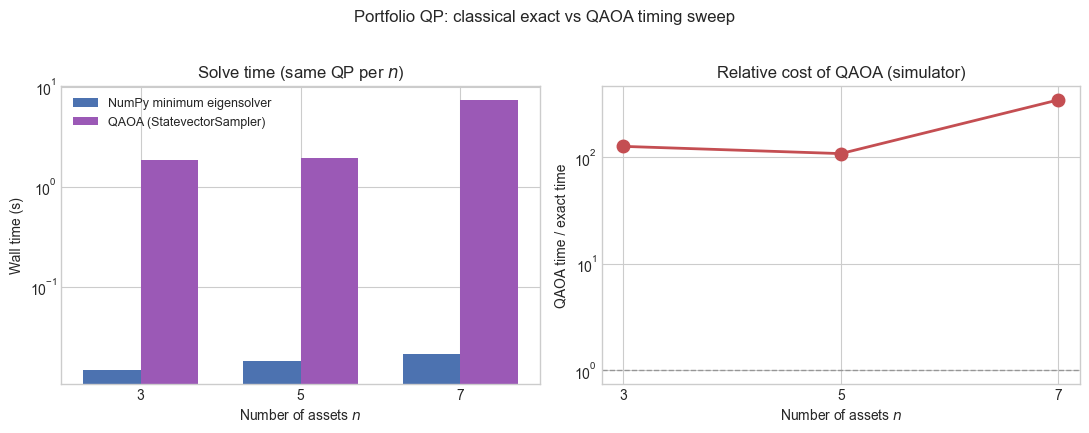

In [5]:
import logging
import warnings
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import SparseEfficiencyWarning

# Quiet Qiskit
for _name in (
    "qiskit",
    "qiskit_algorithms",
    "qiskit_optimization",
    "qiskit_finance",
    "qiskit.passmanager",
    "qiskit.transpiler",
):
    logging.getLogger(_name).setLevel(logging.ERROR)

warnings.filterwarnings("ignore", category=DeprecationWarning)
# SciPy sparse (used inside Qiskit / NumPy eigensolver paths): suppress path-heavy efficiency hints
warnings.filterwarnings("ignore", category=SparseEfficiencyWarning)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

from qiskit_finance.applications import PortfolioOptimization
from qiskit_algorithms import NumPyMinimumEigensolver, QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler
from qiskit_optimization.algorithms import MinimumEigenOptimizer


def run_timings(
    num_assets,
    num_ticks=100,
    seed=42,
    q=0.5,
    budget=2,
    qaoa_reps=1,
    qaoa_maxiter=100,
):
    rng = np.random.default_rng(seed)
    A = rng.standard_normal((num_assets, num_assets)) * 0.01
    true_cov = A @ A.T + np.diag(rng.uniform(0.00005, 0.0005, size=num_assets))
    true_mu = rng.uniform(0.0003, 0.0012, size=num_assets)

    returns = rng.multivariate_normal(true_mu, true_cov, size=num_ticks)
    mu = returns.mean(axis=0)
    sigma = np.cov(returns.T)

    qp = PortfolioOptimization(
        expected_returns=mu,
        covariances=sigma,
        risk_factor=q,
        budget=budget,
    ).to_quadratic_program()

    exact_mes = NumPyMinimumEigensolver()
    t0 = time.perf_counter()
    MinimumEigenOptimizer(exact_mes).solve(qp)
    t_exact = time.perf_counter() - t0

    qaoa = QAOA(
        sampler=StatevectorSampler(),
        optimizer=COBYLA(maxiter=qaoa_maxiter, disp=False),
        reps=qaoa_reps,
    )
    t0 = time.perf_counter()
    MinimumEigenOptimizer(qaoa).solve(qp)
    t_qaoa = time.perf_counter() - t0

    return t_exact, t_qaoa


rows = []
for n in (3, 5, 7):
    te, tq = run_timings(n)
    rows.append((n, te, tq, tq / te if te > 0 else np.nan))

ns = np.array([r[0] for r in rows], dtype=float)
t_exact = np.array([r[1] for r in rows])
t_qaoa = np.array([r[2] for r in rows])
ratio = np.array([r[3] for r in rows])

print()
print(f"{'n':>4}  {'exact [s]':>12}  {'qaoa [s]':>12}  {'qaoa/exact':>12}")
print("-" * 48)
for n, te, tq, r in rows:
    print(f"{n:>4}  {te:12.4f}  {tq:12.4f}  {r:12.1f}x")

# --- plots ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

x = np.arange(len(ns))
w = 0.36
axes[0].bar(x - w / 2, t_exact, w, label="NumPy minimum eigensolver", color="#4C72B0")
axes[0].bar(x + w / 2, t_qaoa, w, label="QAOA (StatevectorSampler)", color="#9B59B6")
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(int(n)) for n in ns])
axes[0].set_xlabel("Number of assets $n$")
axes[0].set_ylabel("Wall time (s)")
axes[0].set_title("Solve time (same QP per $n$)")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].set_yscale("log")

axes[1].plot(ns, ratio, "o-", color="#C44E52", lw=2, markersize=9)
axes[1].axhline(1.0, color="gray", ls="--", lw=1, alpha=0.7)
axes[1].set_xticks(ns)
axes[1].set_xlabel("Number of assets $n$")
axes[1].set_ylabel("QAOA time / exact time")
axes[1].set_title("Relative cost of QAOA (simulator)")
axes[1].set_yscale("log")

fig.suptitle("Portfolio QP: classical exact vs QAOA timing sweep", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## Where QAOA can “outperform” (solution quality, not speed)

We compare **objective values** (lower is better) for the same QP:

| Method | Role |
|--------|------|
| **Exact** | Global optimum (NumPy minimum eigensolver). |
| **QAOA** | Variational heuristic. |
| **Random-$k$** | Draw $k$ **uniform** feasible portfolios (exactly `budget` assets) and take the best — a deliberately weak baseline when $k$ is small. |

If $k$ is tiny, random search often misses good minima; QAOA can still **guide** the search via the variational landscape and end up **closer to optimal** than “best of $k$ random” — that is a fair sense in which QAOA **outperforms** random search **on quality**, while still losing on **wall time** vs exact diagonalization on a laptop simulator.

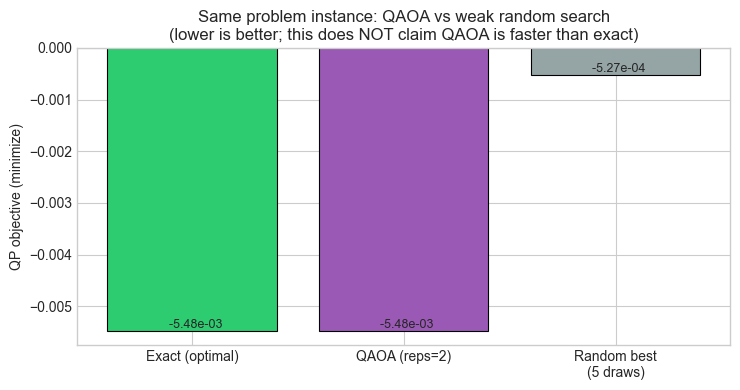

Optimality gap (QAOA − optimal): 0.0000e+00
Optimality gap (random − optimal): 4.9501e-03
→ On this instance, QAOA is closer to optimal than best-of-random (quality win).

Over 12 random problem instances: QAOA at least as close to optimal as best-of-5-random in 12/12 cases (100%).


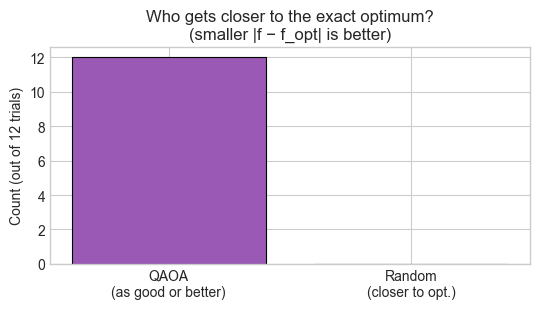

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_finance.applications import PortfolioOptimization
from qiskit_algorithms import NumPyMinimumEigensolver, QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler
from qiskit_optimization.algorithms import MinimumEigenOptimizer


def build_portfolio_qp(num_assets, num_ticks=100, seed=0, q=0.5, budget=2):
    rng = np.random.default_rng(seed)
    A = rng.standard_normal((num_assets, num_assets)) * 0.01
    true_cov = A @ A.T + np.diag(rng.uniform(0.00005, 0.0005, size=num_assets))
    true_mu = rng.uniform(0.0003, 0.0012, size=num_assets)
    returns = rng.multivariate_normal(true_mu, true_cov, size=num_ticks)
    mu = returns.mean(axis=0)
    sigma = np.cov(returns.T)
    return PortfolioOptimization(
        expected_returns=mu,
        covariances=sigma,
        risk_factor=q,
        budget=budget,
    ).to_quadratic_program()


def best_of_random_feasible(qp, n, budget, k, rng):
    """Uniform over feasible supports: exactly `budget` assets chosen."""
    best = np.inf
    for _ in range(k):
        idx = rng.choice(n, size=budget, replace=False)
        x = np.zeros(n)
        x[idx] = 1.0
        v = qp.objective.evaluate(x)
        if v < best:
            best = v
    return float(best)


# --- single illustrative instance (n=7, weak random: few samples) ---
num_assets = 7
budget = 2
qp = build_portfolio_qp(num_assets, seed=123)

exact_res = MinimumEigenOptimizer(NumPyMinimumEigensolver()).solve(qp)
f_opt = float(exact_res.fval)

qaoa = QAOA(
    sampler=StatevectorSampler(),
    optimizer=COBYLA(maxiter=150, disp=False),
    reps=2,
)
f_qaoa = float(MinimumEigenOptimizer(qaoa).solve(qp).fval)

rng = np.random.default_rng(42)
K_RANDOM = 5  # deliberately small → weak baseline
f_rand = best_of_random_feasible(qp, num_assets, budget, K_RANDOM, rng)

labels = ("Exact (optimal)", f"QAOA (reps=2)", f"Random best\n({K_RANDOM} draws)")
vals = np.array([f_opt, f_qaoa, f_rand])
colors = ("#2ecc71", "#9b59b6", "#95a5a6")

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(labels, vals, color=colors, edgecolor="black", linewidth=0.8)
ax.set_ylabel("QP objective (minimize)")
ax.set_title(
    "Same problem instance: QAOA vs weak random search\n"
    "(lower is better; this does NOT claim QAOA is faster than exact)"
)
for i, v in enumerate(vals):
    ax.text(i, v, f"  {v:.2e}", va="bottom", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

gap_q = f_qaoa - f_opt
gap_r = f_rand - f_opt
print(f"Optimality gap (QAOA − optimal): {gap_q:.4e}")
print(f"Optimality gap (random − optimal): {gap_r:.4e}")
if gap_q < gap_r:
    print("→ On this instance, QAOA is closer to optimal than best-of-random (quality win).")
else:
    print("→ On this instance, random was better — try another seed or lower K_RANDOM / tune QAOA.")

# --- Monte Carlo: how often is QAOA closer to optimal than weak random? ---
# (Faster QAOA settings here so the loop finishes in reasonable time; raise N_TRIALS for smoother stats.)
N_TRIALS = 12
K_RANDOM = 5
qaoa_closer = 0
for trial_seed in range(N_TRIALS):
    qp_t = build_portfolio_qp(num_assets, seed=1000 + trial_seed)
    f_opt_t = float(MinimumEigenOptimizer(NumPyMinimumEigensolver()).solve(qp_t).fval)
    qaoa_t = QAOA(
        StatevectorSampler(),
        COBYLA(maxiter=90, disp=False),
        reps=1,
    )
    f_q_t = float(MinimumEigenOptimizer(qaoa_t).solve(qp_t).fval)
    f_r_t = best_of_random_feasible(
        qp_t, num_assets, budget, K_RANDOM, np.random.default_rng(9000 + trial_seed)
    )
    if abs(f_q_t - f_opt_t) <= abs(f_r_t - f_opt_t) + 1e-12:
        qaoa_closer += 1

print(
    f"\nOver {N_TRIALS} random problem instances: "
    f"QAOA at least as close to optimal as best-of-{K_RANDOM}-random in "
    f"{qaoa_closer}/{N_TRIALS} cases ({100*qaoa_closer/N_TRIALS:.0f}%)."
)

fig2, ax2 = plt.subplots(figsize=(5.5, 3.2))
ax2.bar(
    ["QAOA\n(as good or better)", "Random\n(closer to opt.)"],
    [qaoa_closer, N_TRIALS - qaoa_closer],
    color=["#9b59b6", "#95a5a6"],
    edgecolor="black",
    linewidth=0.8,
)
ax2.set_ylabel("Count (out of %d trials)" % N_TRIALS)
ax2.set_title("Who gets closer to the exact optimum?\n(smaller |f − f_opt| is better)")
plt.tight_layout()
plt.show()